In [14]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix  

In [15]:
#read pd from here https://raw.githubusercontent.com/a-nagar/cs4372/refs/heads/main/data/model-results.csv
results = pd.read_csv("https://raw.githubusercontent.com/a-nagar/cs4372/refs/heads/main/data/model-results.csv")

In [16]:
results.head()

,actual,predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [ ]:
# cross tabulation repesents a way to quantitatively analyze the relationship between multiple variables.
#in this case, we are comparing actual vs predicted values, and we can see 
pd.crosstab(results['actual'], results['predicted'], rownames=['Actual'], colnames=['Predicted'])

Predicted,0,1
Actual,,
0,200,40
1,20,100


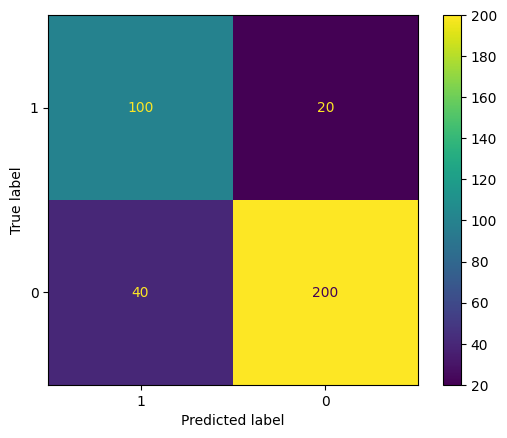

In [22]:
cm_results = confusion_matrix(results['actual'], results['predicted'], labels=[1,0])
ConfusionMatrixDisplay(confusion_matrix=cm_results, display_labels=[1,0]).plot()

In [23]:
# load the CSV from that URL
url = "https://raw.githubusercontent.com/a-nagar/cs4372/refs/heads/main/data/model-results.csv"
df = pd.read_csv(url)

# you’ll need to inspect the column names
# I assume there is a column “prob” for P(+|x) and “true” as the true label (with values +/− or 1/0)

# For this example, let me assume:
#   df["prob"] = probability of positive class
#   df["true"] = 1 for positive, 0 for negative

def expected_cost_predict_plus(p):
    return -1 * p + 1 * (1 - p)

def expected_cost_predict_minus(p):
    return 100 * p + 0 * (1 - p)

# Decide predictions
df["R_plus"] = df["prob"].apply(expected_cost_predict_plus)
df["R_minus"] = df["prob"].apply(expected_cost_predict_minus)
df["pred"] = df.apply(lambda row: 1 if row["R_plus"] < row["R_minus"] else 0, axis=1)

# Now compute total cost
def cost(true, pred):
    # cost matrix:
    # if true = 1 and pred = 1 → cost = -1
    # if true = 1 and pred = 0 → cost = 100
    # if true = 0 and pred = 1 → cost = 1
    # if true = 0 and pred = 0 → cost = 0
    if true == 1 and pred == 1:
        return -1
    if true == 1 and pred == 0:
        return 100
    if true == 0 and pred == 1:
        return 1
    if true == 0 and pred == 0:
        return 0

df["instance_cost"] = df.apply(lambda row: cost(row["true"], row["pred"]), axis=1)
total_cost = df["instance_cost"].sum()
total_cost, df["pred"].mean()

KeyError: 'prob'

Text(0, 0.5, 'True positive rate')

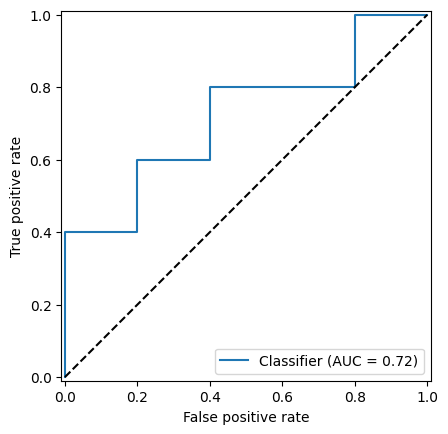

In [ ]:
#now we want to make an roc curve of this data https://raw.githubusercontent.com/a-nagar/cs4372/refs/heads/main/data/roc_disease.csv
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
roc_data = pd.read_csv("https://raw.githubusercontent.com/a-nagar/cs4372/refs/heads/main/data/roc_disease.csv")
RocCurveDisplay.from_predictions(roc_data['actual'], roc_data['pred_prob'])
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')



In [30]:
#find the area under the curve
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(roc_data['actual'], roc_data['pred_prob'])
roc_auc

0.72